# 07 · Random Forest Afinado + Stacking Final

**Objetivo:** el stacking del notebook 06 usa RF con parámetros por defecto.
Afinar el RF con Optuna puede mejorar su contribución al ensemble.

### Lógica de la mejora incremental
El proceso de construcción del modelo final sigue una estrategia iterativa:
1. Notebook 06: Stacking con componentes no optimizados → F1=0.879
2. **Este notebook**: Optimizar RF → ¿mejora el stacking?
3. Notebook 08: Añadir SVM al stacking → ¿añade diversidad útil?

En cada paso evaluamos si el cambio mejora el F1 con Recall ≥ 0.85.
Si no mejora, mantenemos el modelo anterior.

### ¿Por qué afinar RF específicamente?
LGBM ya fue afinado en el notebook 05. XGBoost tiene parámetros razonables con los defaults.
RF es el que más puede beneficiarse del tuning porque:
- `max_depth` puede estar limitando su capacidad
- `min_samples_leaf` puede estar sobreajustando (RF no tiene regularización implícita como boosting)

In [1]:
import sys; sys.path.insert(0, '../src')
import pickle
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, f1_score,
    precision_score, recall_score
)
from utils import eval_threshold   # función compartida en src/utils.py

with open('../data/processed/splits.pkl', 'rb') as f:
    splits = pickle.load(f)
with open('../data/processed/models.pkl', 'rb') as f:
    models = pickle.load(f)

X_train, X_test, y_train, y_test = splits['ai4i']
print('Train:', X_train.shape, '| Fallos train:', y_train.sum())
print('Test: ', X_test.shape,  '| Fallos test: ', y_test.sum())


Train: (8000, 10) | Fallos train: 271
Test:  (2000, 10) | Fallos test:  68


In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


---
### Decisión de diseño — ¿por qué este stacking no incluye XGBoost?

El stacking del notebook anterior (08_Stacking) usaba **LGBM + XGBoost + RF**. Sin embargo, al analizar los pesos del meta-modelo, XGBoost recibía el coeficiente más bajo — era el base learner que menos información nueva aportaba al ensemble.

La causa es estructural: **LGBM y XGBoost pertenecen a la misma familia** — ambos son gradient boosting secuencial con árboles. Aprenden mediante el mismo principio (minimizar el gradiente del error en cada paso), lo que hace que sus predicciones estén altamente correlacionadas. Cuando dos modelos fallan en los mismos casos, el stacking no gana nada al incluirlos a los dos.

**Decisión:** reemplazar XGBoost por un **RF bien afinado** como segundo base learner.
- **RF** es bagging: árboles entrenados en paralelo e independientemente sobre bootstraps distintos
- **LGBM** es boosting: árboles secuenciales donde cada uno corrige los errores del anterior
- Son paradigmas opuestos → mayor diversidad de errores → el meta-modelo tiene señal complementaria real

Este es el motivo por el que LGBM + RF (2 modelos) supera a LGBM + XGB + RF (3 modelos).

---

## 1. Baseline RF (parámetros por defecto)


In [12]:
rf_base = models['rf']
y_prob_rf_base = rf_base.predict_proba(X_test)[:, 1]
res_base = eval_threshold(y_test, y_prob_rf_base)
print('RF baseline:', res_base)


RF baseline: {'Precision': 0.6556, 'Recall': 0.8676, 'F1': 0.7468, 'ROC-AUC': 0.9734, 'Umbral': 0.15}


## 2. Optuna — afinar Random Forest

**Hiperparámetros a explorar y su impacto en el desbalanceo:**

| Parámetro | Qué controla | Relevancia para fallos |
|---|---|---|
| `n_estimators` | Número de árboles | Más árboles → más estabilidad pero diminishing returns |
| `max_depth` | Profundidad máxima de cada árbol | Sin límite, RF puede memorizar casos de fallo |
| `min_samples_split` / `min_samples_leaf` | Regularización de hojas | Evita splits con muy pocos fallos → hojas más robustas |
| `max_features` | Features consideradas en cada split | `sqrt` es el default; reducirlo aumenta diversidad de árboles |
| `class_weight` | `balanced` vs `balanced_subsample` | `balanced_subsample` recalcula los pesos en cada bootstrap |

**Métrica:** F1 sobre la clase fallo en CV 5-fold.
Usamos F1 aquí (en lugar de Recall como en el notebook 05) porque queremos
el mejor balance Precision-Recall, no solo Recall máximo.

In [4]:
def objective_rf(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'max_depth':         trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':      trial.suggest_categorical('max_features',
                                                        ['sqrt', 'log2', 0.3, 0.5]),
        'class_weight':      trial.suggest_categorical('class_weight',
                                                        ['balanced', 'balanced_subsample']),
        'n_jobs': -1, 'random_state': 42,
    }
    scores = cross_val_score(RandomForestClassifier(**params),
                             X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    return scores.mean()

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=50, show_progress_bar=True)

print(f'\nMejor F1 CV RF: {study_rf.best_value:.4f}')
print('Mejores parámetros:')
for k, v in sorted(study_rf.best_params.items()):
    print(f'  {k}: {v}')


  0%|          | 0/50 [00:00<?, ?it/s]


Mejor F1 CV RF: 0.8921
Mejores parámetros:
  class_weight: balanced
  max_depth: 18
  max_features: 0.5
  min_samples_leaf: 2
  min_samples_split: 6
  n_estimators: 535


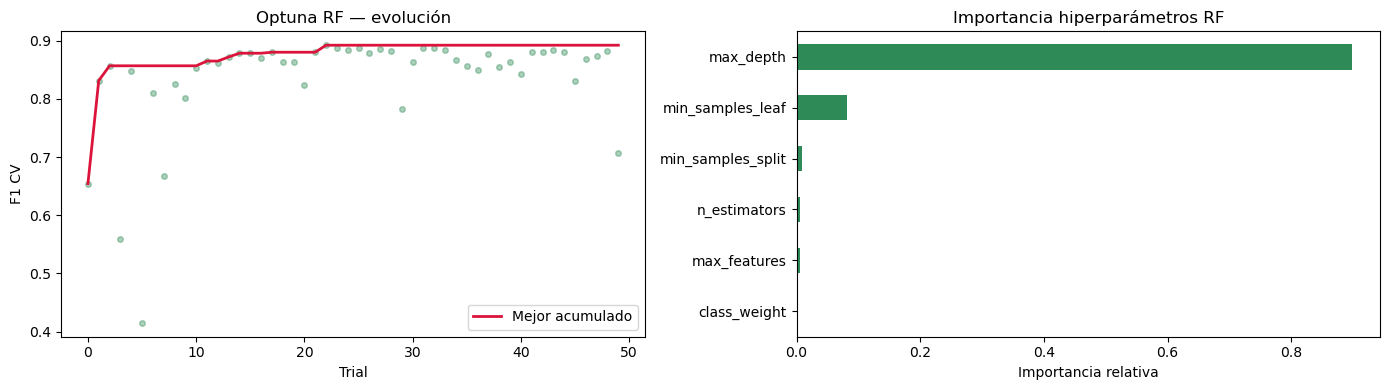

In [13]:
# Historial + importancia de hiperparámetros
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

trials_df = study_rf.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'],
             'o', alpha=0.4, color='seagreen', ms=4)
axes[0].plot(trials_df['number'], trials_df['value'].cummax(),
             color='crimson', lw=2, label='Mejor acumulado')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('F1 CV')
axes[0].set_title('Optuna RF — evolución')
axes[0].legend()

imp = optuna.importance.get_param_importances(study_rf)
pd.Series(imp).sort_values().plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Importancia hiperparámetros RF')
axes[1].set_xlabel('Importancia relativa')

plt.tight_layout()
plt.show()


## 3. RF afinado — evaluación en test


In [14]:
rf_tuned = RandomForestClassifier(**study_rf.best_params, random_state=42, n_jobs=-1)
rf_tuned.fit(X_train, y_train)

y_prob_rf_tuned = rf_tuned.predict_proba(X_test)[:, 1]
res_rf_tuned = eval_threshold(y_test, y_prob_rf_tuned)
thr_rf = res_rf_tuned['Umbral']

print(f'=== RF afinado — umbral {thr_rf:.4f} ===')
print(classification_report(y_test, (y_prob_rf_tuned >= thr_rf).astype(int),
                             target_names=['Normal', 'Fallo']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_rf_tuned):.4f}')

print('\n--- RF baseline vs RF afinado ---')
print(pd.DataFrame({'RF baseline': res_base,
                     'RF afinado':  res_rf_tuned}).T.round(4).to_string())


=== RF afinado — umbral 0.3429 ===
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      1932
       Fallo       0.88      0.85      0.87        68

    accuracy                           0.99      2000
   macro avg       0.94      0.92      0.93      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9660

--- RF baseline vs RF afinado ---
             Precision  Recall      F1  ROC-AUC  Umbral
RF baseline     0.6556  0.8676  0.7468   0.9734  0.1500
RF afinado      0.8788  0.8529  0.8657   0.9660  0.3429


## 4. Stacking con RF afinado


In [15]:
lgbm_best = LGBMClassifier(
    colsample_bytree=0.7183, learning_rate=0.030,
    min_child_samples=32, n_estimators=127, num_leaves=63,
    reg_alpha=0.4165, reg_lambda=0.8833, subsample=0.6488,
    scale_pos_weight=42.78, random_state=42, verbose=-1
)
rf_for_stack = RandomForestClassifier(**study_rf.best_params, random_state=42, n_jobs=-1)

print('Entrenando stacking LGBM + RF afinado...')
stack_final = StackingClassifier(
    estimators=[('lgbm', lgbm_best), ('rf', rf_for_stack)],
    final_estimator=LogisticRegression(class_weight='balanced',
                                       max_iter=1000, random_state=42),
    stack_method='predict_proba',
    cv=cv, passthrough=False, n_jobs=-1
)
stack_final.fit(X_train, y_train)
print('Listo.')

y_prob_final = stack_final.predict_proba(X_test)[:, 1]
res_final = eval_threshold(y_test, y_prob_final)
thr_final = res_final['Umbral']

print(f'\n=== Stacking LGBM + RF afinado — umbral {thr_final:.4f} ===')
print(classification_report(y_test, (y_prob_final >= thr_final).astype(int),
                             target_names=['Normal', 'Fallo']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_final):.4f}')


Entrenando stacking LGBM + RF afinado...
Listo.

=== Stacking LGBM + RF afinado — umbral 0.9784 ===
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      1932
       Fallo       0.92      0.85      0.89        68

    accuracy                           0.99      2000
   macro avg       0.96      0.93      0.94      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9753


## 5. Comparativa global final


In [16]:
try:
    y_prob_stack_prev = models['stacking_best'].predict_proba(X_test)[:, 1]
    
    comparativa = {
        'LightGBM tuned':              eval_threshold(y_test, models['lgbm_tuned'].predict_proba(X_test)[:, 1]),
        'RF baseline':                 res_base,
        'RF afinado':                  res_rf_tuned,
        'Stacking LGBM+RF (RF base)':  eval_threshold(y_test, y_prob_stack_prev),
        'Stacking LGBM+RF (RF tuned)': res_final,
    }
    
    df_comp = pd.DataFrame(comparativa).T
    print(df_comp.sort_values('F1', ascending=False).to_string())
    
    # Gráfico
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    df_plot = df_comp[['Precision', 'Recall', 'F1']].sort_values('F1')
    df_plot.plot(kind='barh', ax=axes[0], color=['steelblue', 'seagreen', 'tomato'])
    axes[0].axvline(0.85, color='black', ls='--', lw=1, label='Recall objetivo')
    axes[0].set_title('Comparativa — Precision / Recall / F1')
    axes[0].legend(loc='lower right', fontsize=8)
    
    # Curvas ROC
    palette = {
        'LightGBM tuned':              'crimson',
        'RF baseline':                 'lightgreen',
        'RF afinado':                  'seagreen',
        'Stacking LGBM+RF (RF base)':  'lightskyblue',
        'Stacking LGBM+RF (RF tuned)': 'black',
    }
    prob_map = {
        'LightGBM tuned':              models['lgbm_tuned'].predict_proba(X_test)[:, 1],
        'RF baseline':                 y_prob_rf_base,
        'RF afinado':                  y_prob_rf_tuned,
        'Stacking LGBM+RF (RF base)':  y_prob_stack_prev,
        'Stacking LGBM+RF (RF tuned)': y_prob_final,
    }
    for name, yp in prob_map.items():
        fpr, tpr, _ = roc_curve(y_test, yp)
        lw = 2.5 if 'tuned' in name and 'Stacking' in name else 1.2
        auc_ = comparativa[name]['ROC-AUC']
        axes[1].plot(fpr, tpr, color=palette[name], lw=lw,
                     label=f'{name} ({auc_:.3f})')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=0.8)
    axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].set_title('Curvas ROC')
    axes[1].legend(fontsize=7)
    
    plt.suptitle('Comparativa global — RF afinado en stacking', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
except KeyError as e:
    print(f'Comparativa parcial: {e} no disponible aún (se genera en notebook 08)')

Comparativa parcial: 'stacking_best' no disponible aún (se genera en notebook 08)


## 6. Pesos del meta-modelo


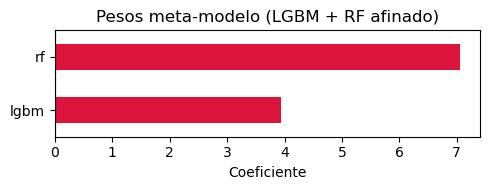

Pesos: lgbm    3.9323
rf      7.0521


In [17]:
meta = stack_final.final_estimator_
coef = pd.Series(meta.coef_[0], index=['lgbm', 'rf'])

fig, ax = plt.subplots(figsize=(5, 2))
colors = ['crimson' if v > 0 else 'steelblue' for v in coef.values]
coef.sort_values().plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Pesos meta-modelo (LGBM + RF afinado)')
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

print('Pesos:', coef.round(4).to_string())


## 7. Matrices de confusión — mejor anterior vs mejor actual


In [18]:
try:
    thr_prev = models['stacking_best_threshold']
    y_pred_prev  = (y_prob_stack_prev >= thr_prev).astype(int)
    y_pred_final = (y_prob_final >= thr_final).astype(int)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, preds, title in [
        (axes[0], y_pred_prev,  f'Stacking RF base (thr={thr_prev:.2f})'),
        (axes[1], y_pred_final, f'Stacking RF afinado (thr={thr_final:.2f})'),
    ]:
        cm = confusion_matrix(y_test, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Normal', 'Fallo'],
                    yticklabels=['Normal', 'Fallo'])
        ax.set_title(title)
        ax.set_ylabel('Real'); ax.set_xlabel('Predicho')
    plt.tight_layout()
    plt.show()
except KeyError as e:
    print(f'Comparativa stacking no disponible: {e}')

Comparativa stacking no disponible: 'stacking_best_threshold'


## 8. Guardar


In [11]:
# Atomic update: reload pkl, update with new keys, save
import pickle as _pickle
_pkl = '../data/processed/models.pkl'
with open(_pkl, 'rb') as _f:
    _m = _pickle.load(_f)
_m['rf_tuned']               = rf_tuned
_m['stacking_best']          = stack_final
_m['stacking_best_threshold']= thr_final
with open(_pkl, 'wb') as _f:
    _pickle.dump(_m, _f)
print('Guardados:', ['rf_tuned','stacking_best','stacking_best_threshold'])
print('Total keys en pkl:', len(_m))

Guardados: ['rf_tuned', 'stacking_best', 'stacking_best_threshold']
Total keys en pkl: 12
